In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
RAW_DIR = Path.cwd().parent / "data" / "raw"

nav_history = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv")
fund_master = pd.read_csv(RAW_DIR / "01_fund_master.csv")
benchmark = pd.read_csv(RAW_DIR / "10_benchmark_indices.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Loaded.")

Loaded.


In [3]:
nav_pivot = nav_history.pivot(index="date", columns="amfi_code", values="nav")
daily_returns = nav_pivot.pct_change().dropna()

print(daily_returns.shape)
daily_returns.head()

(1607, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
def calculate_cagr(nav_series, years):
    end_date = nav_series.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    
    nav_start = nav_series[nav_series.index >= start_date].iloc[0]
    nav_end = nav_series.iloc[-1]
    
    n_years = (nav_series.index[-1] - nav_series[nav_series.index >= start_date].index[0]).days / 365.25
    cagr = (nav_end / nav_start) ** (1 / n_years) - 1
    return cagr * 100

cagr_results = []
for code in nav_pivot.columns:
    fund_nav = nav_pivot[code].dropna()
    row = {"amfi_code": code}
    for years in [1, 3, 5]:
        try:
            row[f"cagr_{years}yr_pct"] = calculate_cagr(fund_nav, years)
        except:
            row[f"cagr_{years}yr_pct"] = None
    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)
cagr_df.head()

,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,-2.225777,1.292353,2.637074
1,100025,3.707553,3.915479,4.458210
2,100033,53.277195,32.433971,30.123153
3,101206,47.963794,28.960211,23.538361
4,101207,-24.000309,-4.151454,7.938765


In [5]:
risk_free_rate = 0.065  # 6.5% annual, per your brief

sharpe_results = []
for code in daily_returns.columns:
    returns = daily_returns[code]
    annualized_return = returns.mean() * 252
    annualized_std = returns.std() * np.sqrt(252)
    sharpe = (annualized_return - risk_free_rate) / annualized_std
    sharpe_results.append({"amfi_code": code, "sharpe_ratio": sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.321019
1,100025,-1.039941
2,100033,0.808268
3,101206,0.717409
4,101207,0.052618


In [6]:
sortino_results = []
for code in daily_returns.columns:
    returns = daily_returns[code]
    annualized_return = returns.mean() * 252
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = (annualized_return - risk_free_rate) / downside_std
    sortino_results.append({"amfi_code": code, "sortino_ratio": sortino})

sortino_df = pd.DataFrame(sortino_results)
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.472822
1,100025,-1.461220
2,100033,1.144216
3,101206,1.063909
4,101207,0.075668


In [10]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.set_index("date")["close_value"]
nifty100_returns = nifty100.pct_change().dropna()

alpha_beta_results = []
for code in daily_returns.columns:
    fund_returns = daily_returns[code]
    aligned = pd.concat([fund_returns, nifty100_returns], axis=1, join="inner").dropna()
    aligned.columns = ["fund", "benchmark"]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(aligned["benchmark"], aligned["fund"])
    
    beta = slope
    alpha = intercept * 252  # annualize
    
    alpha_beta_results.append({"amfi_code": code, "alpha": alpha, "beta": beta})

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [8]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [11]:
max_drawdown_results = []
for code in nav_pivot.columns:
    fund_nav = nav_pivot[code].dropna()
    running_max = fund_nav.cummax()
    drawdown = (fund_nav / running_max) - 1
    max_dd = drawdown.min()
    max_drawdown_results.append({"amfi_code": code, "max_drawdown_pct": max_dd * 100})

max_dd_df = pd.DataFrame(max_drawdown_results)
max_dd_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.734441
1,100025,-4.308264
2,100033,-16.217209
3,101206,-11.291596
4,101207,-35.446916


In [13]:
scorecard = fund_master[["amfi_code", "scheme_name", "expense_ratio_pct"]].copy()
scorecard = scorecard.merge(cagr_df[["amfi_code", "cagr_3yr_pct"]], on="amfi_code")
scorecard = scorecard.merge(sharpe_df, on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code", "alpha"]], on="amfi_code")
scorecard = scorecard.merge(max_dd_df, on="amfi_code")

scorecard["rank_return"] = scorecard["cagr_3yr_pct"].rank(pct=True)
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(pct=True)
scorecard["rank_alpha"] = scorecard["alpha"].rank(pct=True)
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(pct=True, ascending=False)
scorecard["rank_maxdd"] = scorecard["max_drawdown_pct"].rank(pct=True)

scorecard["composite_score"] = (
    0.30 * scorecard["rank_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense"] +
    0.10 * scorecard["rank_maxdd"]
) * 100

scorecard = scorecard.sort_values("composite_score", ascending=False)
scorecard[["scheme_name", "composite_score"]].head(10)

,scheme_name,composite_score
34,Mirae Asset Large Cap Fund - Regular - Growth,86.2500
12,ICICI Pru Midcap Fund - Regular - Growth,82.8750
22,Kotak Flexicap Fund - Regular - Growth,82.0000
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500
11,ICICI Pru Bluechip Fund - Direct - Growth,79.3750
26,Axis Midcap Fund - Regular - Growth,78.2500
0,SBI Bluechip Fund - Regular Plan - Growth,74.1875
36,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875
2,SBI Small Cap Fund - Regular Plan - Growth,68.0000
28,ABSL Frontline Equity Fund - Regular - Growth,67.5625


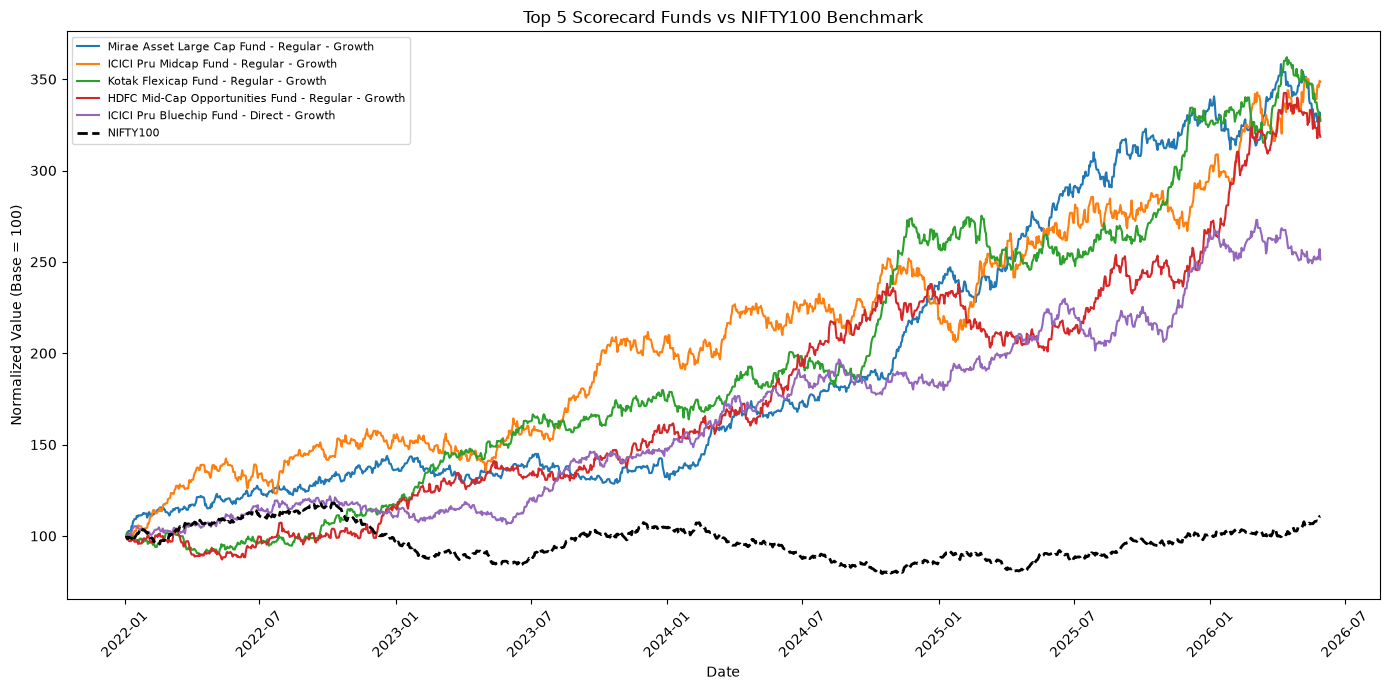

In [14]:
top5_codes = scorecard["amfi_code"].head(5).tolist()

plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values[0]
    fund_nav_normalized = nav_pivot[code] / nav_pivot[code].iloc[0] * 100
    plt.plot(fund_nav_normalized.index, fund_nav_normalized, label=fund_name)

nifty_normalized = nifty100 / nifty100.iloc[0] * 100
plt.plot(nifty_normalized.index, nifty_normalized, label="NIFTY100", color="black", linewidth=2, linestyle="--")

plt.title("Top 5 Scorecard Funds vs NIFTY100 Benchmark")
plt.ylabel("Normalized Value (Base = 100)")
plt.xlabel("Date")
plt.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()